# 03 — Marketing Performance Analysis

## Business question
Should NovoStar continue spending on marketing, and which campaigns or channels deserve the budget?

## Objectives
1. Understand overall sales performance.
2. Evaluate attributed campaign revenue and ROAS.
3. Estimate contribution after product costs and campaign spending.
4. Compare campaign performance by channel.
5. Identify where further analysis is required before making budget decisions.

**Important:** Campaign attribution does not establish incremental sales.

## Imports and loading processed data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR

customers = pd.read_csv(
    PROCESSED_DATA_DIR / "customers.csv",
    parse_dates=["signup_date"],
)

orders = pd.read_csv(
    PROCESSED_DATA_DIR / "orders.csv",
    parse_dates=["order_date"],
)

order_items = pd.read_csv(
    PROCESSED_DATA_DIR / "order_items.csv"
)

products = pd.read_csv(
    PROCESSED_DATA_DIR / "products.csv"
)

campaigns = pd.read_csv(
    PROCESSED_DATA_DIR / "campaigns.csv",
    parse_dates=["start_date", "end_date"],
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Define the analysis population

Two order populations are used:

- **Reporting-period orders:** All recorded orders within the analysis window, regardless of their final status.
- **Revenue-eligible orders:** Completed orders within the analysis window with non-negative recorded amounts.

Reporting-period orders are used to calculate returns and cancellations. Revenue-eligible orders are used for revenue and contribution calculations.

These definitions are applied consistently throughout the notebook.

In [3]:
# Boolean columns may be saved as strings in CSVs.
for column in ["in_reporting_period", "is_revenue_eligible"]:
    if orders[column].dtype == "object":
        orders[column] = orders[column].map({
            "True": True,
            "False": False,
        })

period_orders = orders[
    orders["in_reporting_period"]
].copy()

sales = orders[
    orders["is_revenue_eligible"]
].copy()

print(f"Orders in reporting period: {len(period_orders):,}")
print(f"Revenue-eligible orders: {len(sales):,}")
print(f"Completed revenue: €{sales['total_amount'].sum():,.2f}")

Orders in reporting period: 14,910
Revenue-eligible orders: 12,811
Completed revenue: €4,215,636.42


## 3. Monthly business performance

Monthly performance is evaluated using completed-order revenue, order volume, unique purchasing customers, and average order value.

This provides a business baseline against which campaign activity can be considered.

### 3.1 Monthly revenue and customer activity

The monthly table summarizes financial and purchasing activity throughout the reporting period.


In [5]:
sales["month"] = sales["order_date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    sales.groupby("month")
    .agg(
        revenue_eur=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
    )
    .reset_index()
)

monthly["aov_eur"] = (
    monthly["revenue_eur"] / monthly["orders"]
)

display(monthly.head())

monthly.to_csv(
    TABLES_DIR / "monthly_performance.csv",
    index=False,
)

,month,revenue_eur,orders,customers,aov_eur
0,2024-07-01,105803.22,308,268,343.516948
1,2024-08-01,97231.14,305,269,318.790623
2,2024-09-01,116683.82,358,306,325.932458
3,2024-10-01,127285.65,367,318,346.827384
4,2024-11-01,171678.35,514,412,334.004572


### 3.2 Revenue trend

The revenue visualization shows changes in completed-order revenue over time. Any relationship between campaign timing and business performance will be examined descriptively rather than treated as causal evidence.

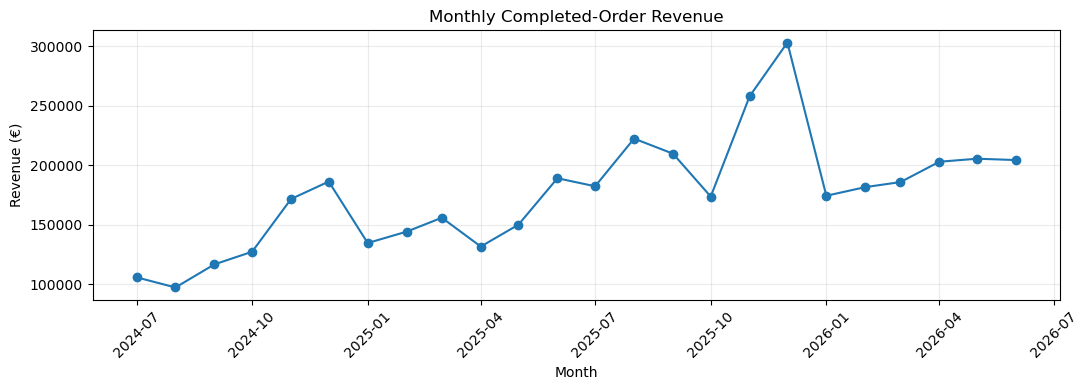

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    monthly["month"],
    monthly["revenue_eur"],
    marker="o",
)

ax.set(
    title="Monthly Completed-Order Revenue",
    xlabel="Month",
    ylabel="Revenue (€)",
)

ax.grid(alpha=0.25)

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "monthly_revenue.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 4. Estimate product contribution

Revenue alone does not measure the economic value of an order.

Estimated product costs are calculated from the quantities purchased and the recorded unit costs of the corresponding products.

**Product contribution = Recorded order revenue − Estimated product costs**

This is an estimate of contribution before marketing expenditure and other operating expenses, including shipping, payment fees, support costs, and overhead.

Product costs are calculated at order level and then aggregated for campaign analysis.

In [7]:
item_economics = order_items.merge(
    products[["product_id", "unit_cost_eur"]],
    on="product_id",
    how="left",
    validate="many_to_one",
)

item_economics["product_cost_eur"] = (
    item_economics["quantity"]
    * item_economics["unit_cost_eur"]
)

order_costs = (
    item_economics.groupby("order_id")["product_cost_eur"]
    .sum()
    .reset_index()
)

sales = sales.merge(
    order_costs,
    on="order_id",
    how="left",
    validate="one_to_one",
)

sales["contribution_eur"] = (
    sales["total_amount"]
    - sales["product_cost_eur"]
)

print(
    f"Completed-order contribution before marketing: "
    f"€{sales['contribution_eur'].sum():,.2f}"
)

Completed-order contribution before marketing: €1,351,210.55


## 5. Campaign performance

Campaigns are evaluated using completed orders carrying a recorded campaign identifier.

The analysis calculates:

- Campaign budget
- Attributed completed orders
- Attributed completed-order revenue
- Attributed purchasing customers
- Estimated attributed product contribution
- Revenue return on advertising spend (ROAS)
- Estimated contribution after campaign budget

**Revenue ROAS = Attributed completed-order revenue ÷ Campaign budget**

**Contribution after budget = Attributed product contribution − Campaign budget**

These figures describe the financial performance of attributed orders. They do not establish incremental revenue or incremental profit.

In [8]:
campaign_sales = sales[
    sales["campaign_id"].notna()
].copy()

campaign_metrics = (
    campaign_sales.groupby("campaign_id")
    .agg(
        attributed_orders=("order_id", "nunique"),
        attributed_revenue_eur=("total_amount", "sum"),
        attributed_contribution_eur=("contribution_eur", "sum"),
        attributed_customers=("customer_id", "nunique"),
    )
    .reset_index()
)

campaign_performance = campaigns.merge(
    campaign_metrics,
    on="campaign_id",
    how="left",
    validate="one_to_one",
)

metric_columns = [
    "attributed_orders",
    "attributed_revenue_eur",
    "attributed_contribution_eur",
    "attributed_customers",
]

campaign_performance[metric_columns] = (
    campaign_performance[metric_columns].fillna(0)
)

campaign_performance["roas"] = (
    campaign_performance["attributed_revenue_eur"]
    / campaign_performance["budget_eur"].replace(0, np.nan)
)

campaign_performance["contribution_after_budget_eur"] = (
    campaign_performance["attributed_contribution_eur"]
    - campaign_performance["budget_eur"]
)

display(
    campaign_performance[
        [
            "campaign_name",
            "channel",
            "budget_eur",
            "attributed_orders",
            "attributed_revenue_eur",
            "roas",
            "attributed_contribution_eur",
            "contribution_after_budget_eur",
        ]
    ].sort_values("roas", ascending=False)
)

campaign_performance.to_csv(
    TABLES_DIR / "campaign_performance.csv",
    index=False,
)

,campaign_name,channel,budget_eur,attributed_orders,attributed_revenue_eur,roas,attributed_contribution_eur,contribution_after_budget_eur
7,Loyalty Points x2,App Push,3000,180,60492.04,20.164013,21581.59,18581.59
2,Xmas Gifts 2024,Newsletter,6000,105,34204.05,5.700675,9301.41,3301.41
5,Easter Family Deals,Newsletter,4500,56,20553.82,4.567516,7739.47,3239.47
11,Spring Clean 2026,Pinterest,16000,195,64649.00,4.040563,18085.99,2085.99
4,Spring Home Refresh,Pinterest,15000,172,49788.24,3.319216,14684.15,-315.85
9,Back to Uni 2025,Instagram,24000,206,64079.74,2.669989,16652.47,-7347.53
3,New Year Fitness,Facebook,18000,145,41169.85,2.287214,11652.04,-6347.96
0,Back to Uni 2024,Instagram,22000,118,38314.85,1.741584,11497.82,-10502.18
6,Mother's Day,Instagram,14000,68,23440.58,1.674327,4184.80,-9815.20
8,Summer Mega Sale,TikTok Influencer,185000,577,124823.19,0.674720,-9911.58,-194911.58


## 6. Performance by marketing channel

Campaign-level results are aggregated by marketing channel to compare budget allocation, attributed revenue, estimated contribution, and revenue efficiency.

Channel-level ROAS is calculated as total attributed revenue divided by total channel budget, rather than averaging individual campaign ROAS values.

Channels may have different objectives and customer audiences, so these comparisons are descriptive.

In [9]:
channel_performance = (
    campaign_performance.groupby("channel")
    .agg(
        spend_eur=("budget_eur", "sum"),
        attributed_orders=("attributed_orders", "sum"),
        attributed_revenue_eur=("attributed_revenue_eur", "sum"),
        attributed_contribution_eur=("attributed_contribution_eur", "sum"),
    )
    .reset_index()
)

channel_performance["roas"] = (
    channel_performance["attributed_revenue_eur"]
    / channel_performance["spend_eur"].replace(0, np.nan)
)

channel_performance["contribution_after_budget_eur"] = (
    channel_performance["attributed_contribution_eur"]
    - channel_performance["spend_eur"]
)

display(
    channel_performance.sort_values(
        "contribution_after_budget_eur",
        ascending=False,
    )
)

channel_performance.to_csv(
    TABLES_DIR / "channel_performance.csv",
    index=False,
)

,channel,spend_eur,attributed_orders,attributed_revenue_eur,attributed_contribution_eur,roas,contribution_after_budget_eur
0,App Push,3000,180,60492.04,21581.59,20.164013,18581.59
4,Newsletter,10500,161,54757.87,17040.88,5.215035,6540.88
5,Pinterest,31000,367,114437.24,32770.14,3.691524,1770.14
1,Facebook,18000,145,41169.85,11652.04,2.287214,-6347.96
3,Instagram,60000,392,125835.17,32335.09,2.097253,-27664.91
2,Google Ads,100000,199,47977.69,11277.19,0.479777,-88722.81
6,TikTok Influencer,185000,577,124823.19,-9911.58,0.674720,-194911.58


## 7. Campaign revenue ROAS

The chart compares attributed completed-order revenue relative to campaign budget.

A ROAS of 1.0× represents €1 in attributed revenue for every €1 of campaign budget. This is a revenue-based reference, not a profitability break-even threshold.

The profitability comparison is developed in the following sections.

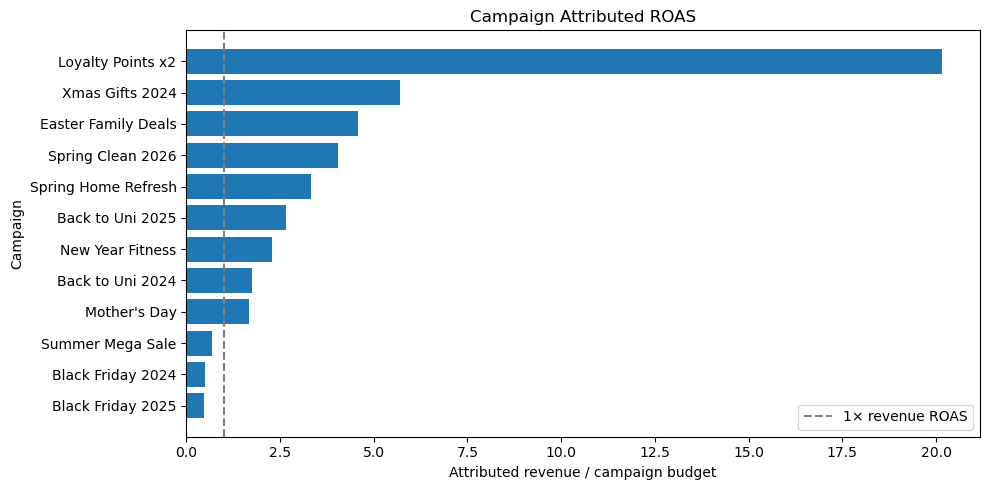

In [10]:
plot_data = campaign_performance.sort_values("roas")

fig, ax = plt.subplots(
    figsize=(10, max(5, len(plot_data) * 0.35))
)

ax.barh(
    plot_data["campaign_name"],
    plot_data["roas"],
)

ax.axvline(
    1,
    linestyle="--",
    color="gray",
    label="1× revenue ROAS",
)

ax.set(
    title="Campaign Attributed ROAS",
    xlabel="Attributed revenue / campaign budget",
    ylabel="Campaign",
)

ax.legend()
plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "campaign_roas.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 8. Overall business and marketing summary

The summary consolidates completed-order revenue, transaction volume, purchasing customers, average order value, campaign-attributed revenue, and campaign budgets.

The share of revenue carrying campaign attribution is reported separately from overall completed-order revenue.

Campaign attribution is not equivalent to proof of marketing influence or incremental sales.

In [12]:
formatted_summary = pd.Series({
    "Completed revenue": f"€{sales['total_amount'].sum():,.2f}",
    "Completed orders": f"{sales['order_id'].nunique():,}",
    "Unique purchasing customers": f"{sales['customer_id'].nunique():,}",
    "Average order value": f"€{sales['total_amount'].mean():,.2f}",
    "Attributed completed revenue": f"€{campaign_sales['total_amount'].sum():,.2f}",
    "Total campaign budgets": f"€{campaigns['budget_eur'].sum():,.2f}",
    "Attributed revenue share": (
        f"{100 * campaign_sales['total_amount'].sum() / sales['total_amount'].sum():.2f}%"
    ),
})

display(formatted_summary.to_frame("Value"))

,Value
Completed revenue,"€4,215,636.42"
Completed orders,"12,811"
Unique purchasing customers,"3,006"
Average order value,€329.06
Attributed completed revenue,"€569,493.05"
Total campaign budgets,"€407,500.00"
Attributed revenue share,13.51%


## 9. Contribution-based campaign performance

Revenue ROAS is supplemented with contribution-based metrics to account for estimated product costs.

**Contribution ROAS = Attributed product contribution ÷ Campaign budget**

**Attributed net return (%) = 100 × (Attributed product contribution − Campaign budget) ÷ Campaign budget**

These measures incorporate estimated product costs and campaign budgets, but exclude other operating costs. They remain attribution-based accounting metrics rather than causal estimates of marketing profitability.

In [16]:
campaign_performance["contribution_roas"] = (
    campaign_performance["attributed_contribution_eur"]
    / campaign_performance["budget_eur"].replace(0, np.nan)
)

campaign_performance["attributed_net_return_pct"] = (
    100
    * campaign_performance["contribution_after_budget_eur"]
    / campaign_performance["budget_eur"].replace(0, np.nan)
)

display(
    campaign_performance[
        [
            "campaign_name",
            "channel",
            "budget_eur",
            "roas",
            "contribution_roas",
            "contribution_after_budget_eur",
            "attributed_net_return_pct",
        ]
    ].sort_values("contribution_roas", ascending=False)
)

,campaign_name,channel,budget_eur,roas,contribution_roas,contribution_after_budget_eur,attributed_net_return_pct
7,Loyalty Points x2,App Push,3000,20.164013,7.193863,18581.59,619.386333
5,Easter Family Deals,Newsletter,4500,4.567516,1.719882,3239.47,71.988222
2,Xmas Gifts 2024,Newsletter,6000,5.700675,1.550235,3301.41,55.023500
11,Spring Clean 2026,Pinterest,16000,4.040563,1.130374,2085.99,13.037437
4,Spring Home Refresh,Pinterest,15000,3.319216,0.978943,-315.85,-2.105667
9,Back to Uni 2025,Instagram,24000,2.669989,0.693853,-7347.53,-30.614708
3,New Year Fitness,Facebook,18000,2.287214,0.647336,-6347.96,-35.266444
0,Back to Uni 2024,Instagram,22000,1.741584,0.522628,-10502.18,-47.737182
6,Mother's Day,Instagram,14000,1.674327,0.298914,-9815.20,-70.108571
1,Black Friday 2024,Google Ads,48000,0.492262,0.127404,-41884.60,-87.259583


### 9.1 Estimated contribution after campaign budget

This visualization compares estimated attributed contribution after subtracting the corresponding campaign budget.

The zero reference line distinguishes positive and negative accounting outcomes under the assumptions used in this analysis.

The chart does not represent estimated incremental profit.

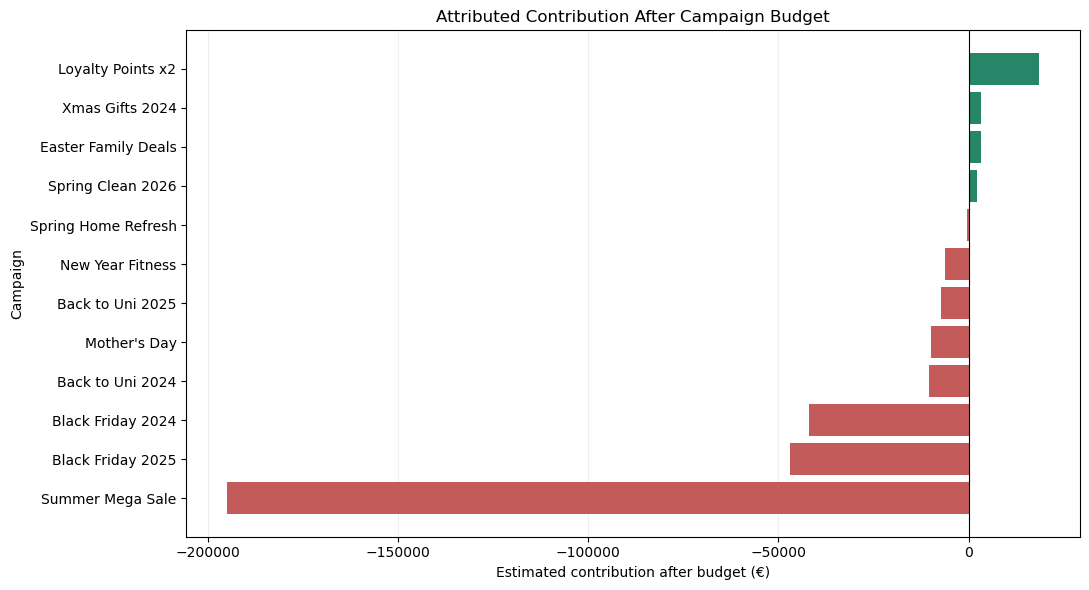

In [17]:
plot_data = campaign_performance.sort_values(
    "contribution_after_budget_eur"
)

values = plot_data["contribution_after_budget_eur"]

colors = np.where(values >= 0, "#278568", "#C45B5B")

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_data["campaign_name"],
    values,
    color=colors,
)

ax.axvline(0, color="black", linewidth=0.8)

ax.set(
    title="Attributed Contribution After Campaign Budget",
    xlabel="Estimated contribution after budget (€)",
    ylabel="Campaign",
)

ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "campaign_contribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 10. Campaign returns and cancellations

Campaign-attributed orders are assessed by recorded order status.

For each campaign, the following metrics are calculated:

- **Return rate:** Returned orders divided by all attributed reporting-period orders.
- **Cancellation rate:** Cancelled orders divided by all attributed reporting-period orders.

Returned and cancelled orders are excluded from the primary completed-order revenue calculation.

These rates describe recorded order outcomes; they do not capture partial returns, refund-processing expenses, or subsequent changes in status.

In [19]:
display(
    campaign_performance[
        [
            "campaign_name",
            "channel",
            "return_rate_pct",
            "cancellation_rate_pct",
            "roas",
            "contribution_roas",
        ]
    ].sort_values("return_rate_pct", ascending=False)
)

,campaign_name,channel,return_rate_pct,cancellation_rate_pct,roas,contribution_roas
6,Mother's Day,Instagram,14.457831,3.614458,1.674327,0.298914
10,Black Friday 2025,Google Ads,13.888889,2.083333,0.468252,0.099265
0,Back to Uni 2024,Instagram,12.857143,2.857143,1.741584,0.522628
3,New Year Fitness,Facebook,12.209302,2.906977,2.287214,0.647336
8,Summer Mega Sale,TikTok Influencer,11.824818,3.795620,0.674720,-0.053576
9,Back to Uni 2025,Instagram,10.126582,2.953586,2.669989,0.693853
11,Spring Clean 2026,Pinterest,9.909910,1.801802,4.040563,1.130374
2,Xmas Gifts 2024,Newsletter,9.600000,6.400000,5.700675,1.550235
4,Spring Home Refresh,Pinterest,9.595960,3.535354,3.319216,0.978943
7,Loyalty Points x2,App Push,9.569378,3.349282,20.164013,7.193863


### 10.1 Return rate comparison

The following chart compares the percentage of campaign-attributed orders recorded as returned.

Return rates are considered alongside revenue and contribution to assess the quality of recorded campaign conversions.

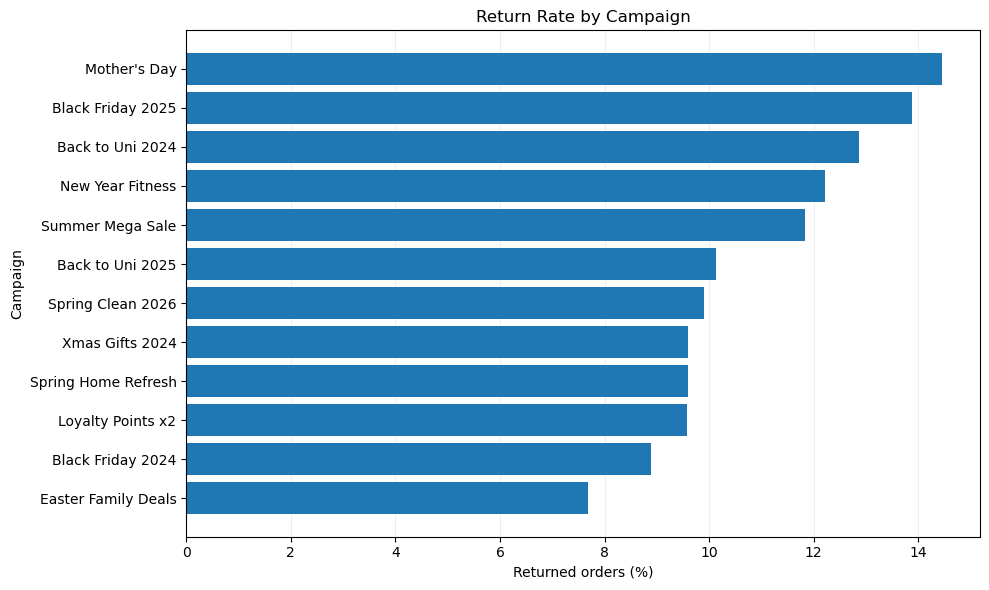

In [21]:
plot_data = campaign_performance.sort_values("return_rate_pct")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["campaign_name"],
    plot_data["return_rate_pct"],
)

ax.set(
    title="Return Rate by Campaign",
    xlabel="Returned orders (%)",
    ylabel="Campaign",
)

ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "campaign_return_rates.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 11. Customer purchasing behavior by acquisition channel

Campaign performance is supplemented with customer-level purchasing measures.

For each acquisition channel, the analysis examines:

- Number of customers with at least one eligible completed order.
- Percentage of those customers with two or more eligible completed orders.
- Average observed completed-order revenue per purchasing customer.

These are descriptive measures of observed purchasing behavior, not lifetime value or causal retention estimates.

Customers acquired at different times may have unequal opportunities to make repeat purchases. Acquisition channel is also distinct from the marketing channel attributed to an individual order.

In [23]:
customer_quality_summary = (
    customer_quality.groupby("acquisition_channel")
    .agg(
        purchasing_customers=("customer_id", "nunique"),
        multi_order_customer_share_pct=(
            "repeat_customer",
            lambda x: x.mean() * 100,
        ),
        avg_observed_revenue_per_customer_eur=(
            "revenue_eur", "mean"
        ),
    )
    .reset_index()
)

display(
    customer_quality_summary.sort_values(
        "multi_order_customer_share_pct",
        ascending=False,
    )
)

,acquisition_channel,purchasing_customers,multi_order_customer_share_pct,avg_observed_revenue_per_customer_eur
4,Referral,413,90.799031,1776.333705
2,Organic Search,728,87.774725,1578.978475
1,Newsletter,258,87.596899,1476.162364
0,Direct,500,87.400000,1481.580560
3,Paid Social,1107,57.994580,1093.833875


## 12. Consolidated campaign comparison

The final campaign table brings together revenue efficiency, estimated contribution, campaign budget, and order outcomes.

This table forms the primary evidence base for the marketing investment recommendation developed in `REPORT.md`.

Campaign results remain descriptive because the available datasets do not contain a verified randomized control group or a comprehensive record of marketing exposure.

In [24]:
final_campaign_table = campaign_performance[
    [
        "campaign_id",
        "campaign_name",
        "channel",
        "budget_eur",
        "attributed_orders",
        "attributed_revenue_eur",
        "roas",
        "attributed_contribution_eur",
        "contribution_roas",
        "contribution_after_budget_eur",
        "attributed_net_return_pct",
        "return_rate_pct",
        "cancellation_rate_pct",
    ]
].sort_values(
    "contribution_after_budget_eur",
    ascending=False,
)

display(
    final_campaign_table.style.format({
        "budget_eur": "€{:,.2f}",
        "attributed_revenue_eur": "€{:,.2f}",
        "attributed_contribution_eur": "€{:,.2f}",
        "contribution_after_budget_eur": "€{:,.2f}",
        "roas": "{:.2f}×",
        "contribution_roas": "{:.2f}×",
        "attributed_net_return_pct": "{:.1f}%",
        "return_rate_pct": "{:.1f}%",
        "cancellation_rate_pct": "{:.1f}%",
    })
)

final_campaign_table.to_csv(
    TABLES_DIR / "campaign_performance.csv",
    index=False,
)

channel_performance.to_csv(
    TABLES_DIR / "channel_performance.csv",
    index=False,
)

customer_quality_summary.to_csv(
    TABLES_DIR / "customer_quality.csv",
    index=False,
)

monthly.to_csv(
    TABLES_DIR / "monthly_performance.csv",
    index=False,
)

print("Analysis tables exported successfully.")

,campaign_id,campaign_name,channel,budget_eur,attributed_orders,attributed_revenue_eur,roas,attributed_contribution_eur,contribution_roas,contribution_after_budget_eur,attributed_net_return_pct,return_rate_pct,cancellation_rate_pct
7,C08,Loyalty Points x2,App Push,"€3,000.00",180,"€60,492.04",20.16×,"€21,581.59",7.19×,"€18,581.59",619.4%,9.6%,3.3%
2,C03,Xmas Gifts 2024,Newsletter,"€6,000.00",105,"€34,204.05",5.70×,"€9,301.41",1.55×,"€3,301.41",55.0%,9.6%,6.4%
5,C06,Easter Family Deals,Newsletter,"€4,500.00",56,"€20,553.82",4.57×,"€7,739.47",1.72×,"€3,239.47",72.0%,7.7%,6.2%
11,C12,Spring Clean 2026,Pinterest,"€16,000.00",195,"€64,649.00",4.04×,"€18,085.99",1.13×,"€2,085.99",13.0%,9.9%,1.8%
4,C05,Spring Home Refresh,Pinterest,"€15,000.00",172,"€49,788.24",3.32×,"€14,684.15",0.98×,€-315.85,-2.1%,9.6%,3.5%
3,C04,New Year Fitness,Facebook,"€18,000.00",145,"€41,169.85",2.29×,"€11,652.04",0.65×,"€-6,347.96",-35.3%,12.2%,2.9%
9,C10,Back to Uni 2025,Instagram,"€24,000.00",206,"€64,079.74",2.67×,"€16,652.47",0.69×,"€-7,347.53",-30.6%,10.1%,3.0%
6,C07,Mother's Day,Instagram,"€14,000.00",68,"€23,440.58",1.67×,"€4,184.80",0.30×,"€-9,815.20",-70.1%,14.5%,3.6%
0,C01,Back to Uni 2024,Instagram,"€22,000.00",118,"€38,314.85",1.74×,"€11,497.82",0.52×,"€-10,502.18",-47.7%,12.9%,2.9%
1,C02,Black Friday 2024,Google Ads,"€48,000.00",78,"€23,628.58",0.49×,"€6,115.40",0.13×,"€-41,884.60",-87.3%,8.9%,4.4%


Analysis tables exported successfully.


## 14. New versus existing customers by campaign

Campaign-attributed completed orders are classified according to each customer's previous completed-order history.

- **First purchase:** The customer's first observed completed purchase.
- **Existing customer:** The customer had at least one earlier completed purchase.

This helps distinguish campaigns associated with customer acquisition from those associated with repeat purchasing.

The classification is based on observed transaction history and does not establish whether marketing caused the purchase. Orders with uncertain historical dates may affect classification.

In [25]:
history = orders.loc[
    orders["status"].eq("completed")
    & orders["order_date"].notna()
    & ~orders["flag_placeholder_date"].astype(bool),
    ["order_id", "customer_id", "order_date"],
].copy()

history = history.sort_values(
    ["customer_id", "order_date", "order_id"]
)

# First observed completed purchase date per customer
first_purchase = (
    history.groupby("customer_id")["order_date"]
    .min()
    .rename("first_purchase_date")
)

campaign_customer_orders = campaign_sales.merge(
    first_purchase,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

# Same-day purchases are treated as first-day purchases;
# ordering within a day cannot be established reliably.
campaign_customer_orders["customer_type"] = np.where(
    campaign_customer_orders["order_date"].dt.normalize()
    == campaign_customer_orders["first_purchase_date"].dt.normalize(),
    "First purchase",
    "Existing customer",
)

customer_mix = (
    campaign_customer_orders.groupby(
        ["campaign_id", "customer_type"]
    )["order_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["First purchase", "Existing customer"], fill_value=0)
)

customer_mix["total_orders"] = customer_mix.sum(axis=1)
customer_mix["existing_order_share_pct"] = (
    100
    * customer_mix["Existing customer"]
    / customer_mix["total_orders"]
)

customer_mix = (
    campaigns[["campaign_id", "campaign_name"]]
    .merge(
        customer_mix.reset_index(),
        on="campaign_id",
        how="left",
    )
    .fillna({
        "First purchase": 0,
        "Existing customer": 0,
        "total_orders": 0,
    })
)

display(
    customer_mix.sort_values(
        "existing_order_share_pct",
        ascending=False,
    )
)

,campaign_id,campaign_name,First purchase,Existing customer,total_orders,existing_order_share_pct
10,C11,Black Friday 2025,12,109,121,90.082645
7,C08,Loyalty Points x2,28,152,180,84.444444
4,C05,Spring Home Refresh,30,142,172,82.558140
9,C10,Back to Uni 2025,37,169,206,82.038835
11,C12,Spring Clean 2026,41,154,195,78.974359
5,C06,Easter Family Deals,13,43,56,76.785714
2,C03,Xmas Gifts 2024,25,80,105,76.190476
6,C07,Mother's Day,17,51,68,75.000000
3,C04,New Year Fitness,37,108,145,74.482759
1,C02,Black Friday 2024,22,56,78,71.794872


## 15. Incrementality sensitivity analysis

Campaign attribution does not measure how much contribution marketing actually created.

To examine the consequences of this uncertainty, we model scenarios in which **25%, 50%, 75%, or 100%** of campaign-attributed product contribution is incremental.

For each scenario:

**Hypothetical incremental contribution after budget = Attributed product contribution × Assumed incremental share − Campaign budget**

We also calculate the **required incremental share** at which estimated incremental contribution would equal the campaign budget.

**Required incremental share = Campaign budget ÷ Attributed product contribution**

A required share above 100% indicates that the campaign cannot break even under this simplified model, even if all recorded attributed contribution is incremental.

These are illustrative scenarios, not estimates of actual incrementality. The model assumes incremental product contribution scales proportionally with the scenario percentage and excludes other operating costs.

In [26]:
scenarios = [0.25, 0.50, 0.75, 1.00]

sensitivity = campaign_performance[
    [
        "campaign_name",
        "budget_eur",
        "attributed_contribution_eur",
    ]
].copy()

for share in scenarios:
    sensitivity[f"net_at_{int(share * 100)}pct_eur"] = (
        sensitivity["attributed_contribution_eur"] * share
        - sensitivity["budget_eur"]
    )

sensitivity["required_incremental_share_pct"] = np.where(
    sensitivity["attributed_contribution_eur"] > 0,
    100 * sensitivity["budget_eur"]
    / sensitivity["attributed_contribution_eur"],
    np.inf,
)

display(
    sensitivity.style.format({
        "budget_eur": "€{:,.0f}",
        "attributed_contribution_eur": "€{:,.0f}",
        "net_at_25pct_eur": "€{:,.0f}",
        "net_at_50pct_eur": "€{:,.0f}",
        "net_at_75pct_eur": "€{:,.0f}",
        "net_at_100pct_eur": "€{:,.0f}",
        "required_incremental_share_pct": "{:.1f}%",
    })
)

sensitivity.to_csv(
    TABLES_DIR / "incrementality_sensitivity.csv",
    index=False,
)

,campaign_name,budget_eur,attributed_contribution_eur,net_at_25pct_eur,net_at_50pct_eur,net_at_75pct_eur,net_at_100pct_eur,required_incremental_share_pct
0,Back to Uni 2024,"€22,000","€11,498","€-19,126","€-16,251","€-13,377","€-10,502",191.3%
1,Black Friday 2024,"€48,000","€6,115","€-46,471","€-44,942","€-43,413","€-41,885",784.9%
2,Xmas Gifts 2024,"€6,000","€9,301","€-3,675","€-1,349",€976,"€3,301",64.5%
3,New Year Fitness,"€18,000","€11,652","€-15,087","€-12,174","€-9,261","€-6,348",154.5%
4,Spring Home Refresh,"€15,000","€14,684","€-11,329","€-7,658","€-3,987",€-316,102.2%
5,Easter Family Deals,"€4,500","€7,739","€-2,565",€-630,"€1,305","€3,239",58.1%
6,Mother's Day,"€14,000","€4,185","€-12,954","€-11,908","€-10,861","€-9,815",334.5%
7,Loyalty Points x2,"€3,000","€21,582","€2,395","€7,791","€13,186","€18,582",13.9%
8,Summer Mega Sale,"€185,000","€-9,912","€-187,478","€-189,956","€-192,434","€-194,912",inf%
9,Back to Uni 2025,"€24,000","€16,652","€-19,837","€-15,674","€-11,511","€-7,348",144.1%


## 16. Contribution ROAS and estimated break-even

Contribution ROAS compares estimated campaign-attributed product contribution against campaign budget.

A contribution ROAS of **1.0×** indicates that recorded attributed contribution exactly covers the campaign budget, before other business expenses.

Values below 1.0× indicate that recorded attributed contribution is insufficient to cover budget. Values above 1.0× indicate a positive attributed contribution surplus under the model.

This is an accounting break-even threshold, not an incremental-profit threshold.

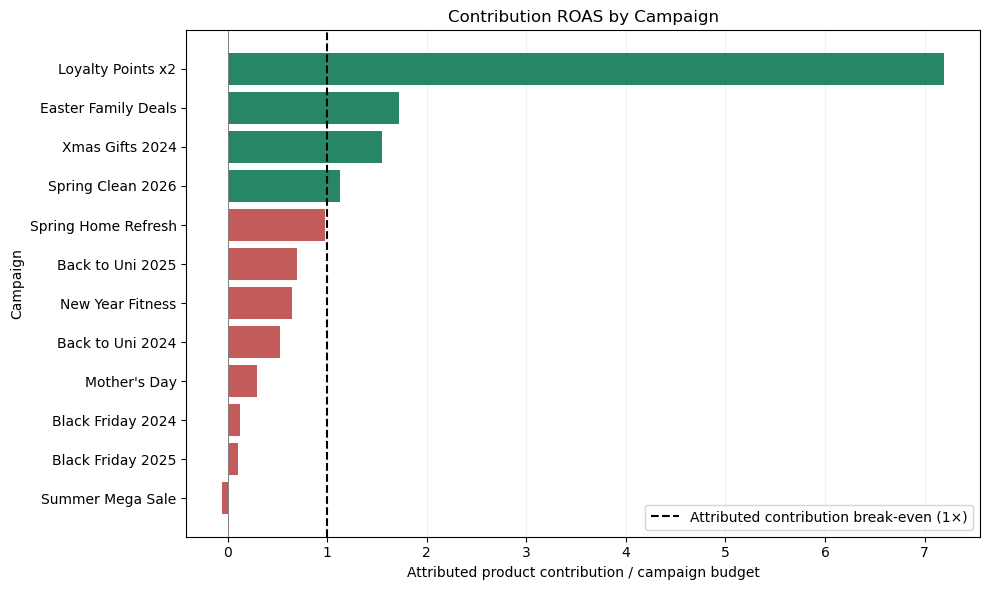

In [27]:
plot_data = campaign_performance.sort_values("contribution_roas")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["campaign_name"],
    plot_data["contribution_roas"],
    color=np.where(
        plot_data["contribution_roas"] >= 1,
        "#278568",
        "#C45B5B",
    ),
)

ax.axvline(
    1,
    color="black",
    linestyle="--",
    label="Attributed contribution break-even (1×)",
)

ax.axvline(0, color="gray", linewidth=0.7)

ax.set(
    title="Contribution ROAS by Campaign",
    xlabel="Attributed product contribution / campaign budget",
    ylabel="Campaign",
)

ax.legend()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "campaign_contribution_roas.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 17. Historical sales comparison

Weekly completed-order revenue is compared with revenue from the corresponding period 52 weeks earlier.

This provides context for seasonality and changes in underlying business performance.

Weeks are also flagged when at least one campaign was active, allowing descriptive comparison of campaign and non-campaign periods.

This comparison does not establish campaign incrementality. Campaign scheduling is not random, campaigns can overlap, and customer demand may differ between years. Revenue changes after campaigns likewise cannot automatically be interpreted as purchase displacement.

In [28]:
weekly = (
    sales.set_index("order_date")
    .resample("W-SUN")["total_amount"]
    .sum()
    .rename("revenue_eur")
    .to_frame()
)

weekly["revenue_52w_ago_eur"] = weekly["revenue_eur"].shift(52)

# Mark a week active if it overlaps any campaign.
weekly["week_start"] = weekly.index - pd.Timedelta(days=6)

weekly["campaign_active"] = [
    (
        (campaigns["start_date"] <= week_end)
        & (campaigns["end_date"] >= week_start)
    ).any()
    for week_start, week_end in zip(weekly["week_start"], weekly.index)
]

weekly["yoy_change_pct"] = (
    100
    * (
        weekly["revenue_eur"] /
        weekly["revenue_52w_ago_eur"].replace(0, np.nan)
        - 1
    )
)

display(weekly.tail(15))

weekly.to_csv(
    TABLES_DIR / "weekly_baseline.csv"
)

,revenue_eur,revenue_52w_ago_eur,week_start,campaign_active,yoy_change_pct
order_date,,,,,
2026-03-29,47870.15,33373.80,2026-03-23,True,43.436318
2026-04-05,30605.24,32237.22,2026-03-30,True,-5.062409
2026-04-12,57104.84,27158.90,2026-04-06,True,110.261977
2026-04-19,55291.09,32956.02,2026-04-13,False,67.772352
2026-04-26,43583.13,25069.30,2026-04-20,False,73.850606
2026-05-03,45682.00,32264.44,2026-04-27,False,41.586217
2026-05-10,47467.27,30080.67,2026-05-04,False,57.799909
2026-05-17,54674.37,36513.01,2026-05-11,False,49.739422
2026-05-24,45285.73,30387.33,2026-05-18,False,49.028329


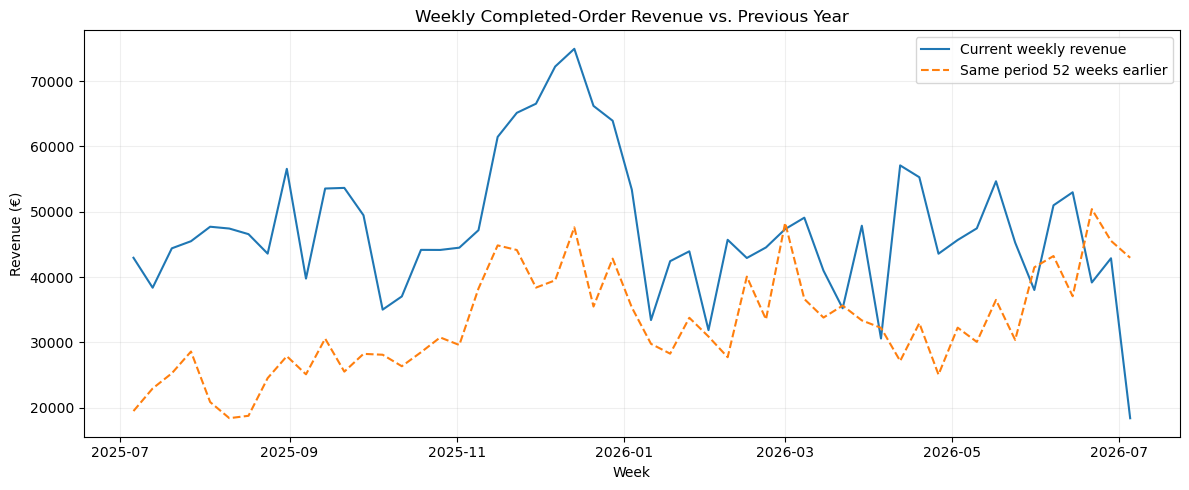

In [29]:
plot_data = weekly.dropna(
    subset=["revenue_52w_ago_eur"]
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_data.index,
    plot_data["revenue_eur"],
    label="Current weekly revenue",
)

ax.plot(
    plot_data.index,
    plot_data["revenue_52w_ago_eur"],
    linestyle="--",
    label="Same period 52 weeks earlier",
)

ax.set(
    title="Weekly Completed-Order Revenue vs. Previous Year",
    xlabel="Week",
    ylabel="Revenue (€)",
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "weekly_revenue_yoy.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 18. Attributed versus unattributed revenue over time

Completed-order revenue is divided into orders with and without a recorded campaign identifier.

The purpose is to understand attribution coverage and whether it changes over time.

Unattributed revenue is **not assumed to be organic or unaffected by marketing**. It represents orders with no recorded campaign attribution and cannot serve as an experimental control group.

In [30]:
attribution_trend = (
    sales.assign(
        attribution_type=np.where(
            sales["campaign_id"].notna(),
            "Attributed",
            "Unattributed",
        )
    )
    .groupby(["month", "attribution_type"])["total_amount"]
    .sum()
    .unstack(fill_value=0)
)

attribution_trend["unattributed_share_pct"] = (
    100 * attribution_trend["Unattributed"]
    / attribution_trend[["Attributed", "Unattributed"]].sum(axis=1)
)

display(attribution_trend)

attribution_trend.to_csv(
    TABLES_DIR / "attribution_trend.csv"
)

attribution_type,Attributed,Unattributed,unattributed_share_pct
month,,,
2024-07-01,0.00,105803.22,100.000000
2024-08-01,0.00,97231.14,100.000000
2024-09-01,38314.85,78368.97,67.163528
2024-10-01,0.00,127285.65,100.000000
2024-11-01,18474.13,153204.22,89.239103
2024-12-01,39358.50,146989.91,78.879079
2025-01-01,41169.85,93468.69,69.421943
2025-02-01,0.00,144209.63,100.000000
2025-03-01,34932.45,120979.17,77.594710


# Final Findings — NovoStar Marketing Analysis

**Period:** July 2024 – June 2026

## Executive Summary

**Recommendation: Continue marketing selectively, but do not increase the overall budget yet.**

NovoStar spent €407,500 in campaign budgets and recorded €569,493 in attributed revenue. However, after estimated product costs and campaign budgets, the attributed contribution is **−€290,755**.

This does not prove marketing caused a loss. It shows that recorded campaign sales alone do not justify the spending.

## 1. Overall Performance

| Metric | Result |
|---|---:|
| Total completed revenue | €4.22M |
| Campaign-attributed revenue | €569,493 |
| Campaign budgets | €407,500 |
| Revenue ROAS | 1.40× |
| Contribution after budgets | **−€290,755** |

**Key insight:** Revenue ROAS looks positive, but product costs change the picture significantly.

## 2. Which Campaigns Perform Best?

| Campaign | Contribution ROAS | Contribution after budget |
|---|---:|---:|
| Loyalty Points x2 | 7.19× | +€18,582 |
| Xmas Gifts 2024 | 1.55× | +€3,301 |
| Easter Family Deals | 1.72× | +€3,239 |
| Spring Clean 2026 | 1.13× | +€2,086 |
| Black Friday 2024 | 0.13× | −€41,885 |
| Black Friday 2025 | 0.10× | −€46,838 |
| Summer Mega Sale | −0.05× | −€194,912 |

**Key insight:** Smaller loyalty and newsletter campaigns show stronger attributed economics. Large campaigns account for most of the negative contribution.

## 3. Summer Mega Sale: Acquisition vs. Profitability

Summer Mega Sale generated **452 first-purchase orders**, representing **78% of its attributed completed orders**.

However:

- Budget: €185,000
- Attributed revenue: €124,823
- Contribution after budget: **−€194,912**

**Key insight:** The campaign attracts first-time buyers, but their immediate purchases do not cover the campaign's costs. Future customer value must be measured before repeating it at this scale.

First-purchase orders are not proof of incremental customer acquisition.

## 4. Customer Quality

| Acquisition channel | Customers with multiple orders | Average observed revenue/customer |
|---|---:|---:|
| Referral | 90.8% | €1,776 |
| Organic Search | 87.8% | €1,579 |
| Newsletter | 87.6% | €1,476 |
| Paid Social | 58.0% | €1,094 |

**Key insight:** Paid Social customers show lower observed repeat purchasing and revenue. However, differences in customer tenure may explain part of this gap.

## 5. Incrementality Sensitivity

How much attributed product contribution must be genuinely incremental to cover campaign budgets?

| Campaign | Required incremental share |
|---|---:|
| Loyalty Points x2 | 13.9% |
| Easter Family Deals | 58.1% |
| Xmas Gifts 2024 | 64.5% |
| Spring Clean 2026 | 88.5% |
| Spring Home Refresh | 102.2% |
| Black Friday 2025 | 1,007.4% |
| Summer Mega Sale | No break-even within model |

**Key insight:** At the hypothetical 50% incrementality scenario, only Loyalty Points x2 breaks even. Most campaigns need unusually high incremental contribution or additional customer value to justify their budgets.

These are scenarios, not measured causal effects.

## 6. Sales Beyond Campaign Attribution

Only **13.51% of completed revenue** carries a campaign identifier. Revenue also remains substantial during periods without active campaigns.

**Key insight:** Campaign attribution captures only part of the business. Unattributed sales are not necessarily unaffected by marketing.

## 7. Recommended Actions

| Action | Recommendation |
|---|---|
| Loyalty and newsletter campaigns | Maintain controlled spending and test incremental impact |
| Summer Mega Sale | Do not repeat at the same scale without customer lifetime value evidence |
| Black Friday Google Ads | Review and reduce spending risk |
| Pinterest campaigns | Optimize individually |
| Future large campaigns | Introduce randomized holdout tests |

## Final Verdict

**Keep marketing, but change how the money is spent and measured.**

The current data identifies promising campaigns and significant financial risks, but it cannot prove how much additional profit marketing creates.

NovoStar should prioritize **contribution over revenue ROAS**, measure the longer-term value of newly acquired customers, and require evidence of incremental impact before increasing its marketing budget.

*Limitations: Financial contribution excludes some operating costs; attribution does not establish causality; and some underlying transaction and date records have known quality issues.*